In [1]:
"""
Implement FEMA model to train on the stocks to get a finger print of each 
then use some kind of temporal model (SARIMA, ARIMA, exponential smoothing, triple exponential smoothing (seasonal & yearly)) to predict the FEMA value for next month
Train a model (example can be LSTM) to predict the "unpredicatble" movement of the stock (what isnt obtained in the FEMA data/signal)

"""

'\nImplement FEMA model to train on the stocks to get a finger print of each \nthen use some kind of temporal model (SARIMA, ARIMA, exponential smoothing, triple exponential smoothing (seasonal & yearly)) to predict the FEMA value for next month\nTrain a model (example can be LSTM) to predict the "unpredicatble" movement of the stock (what isnt obtained in the FEMA data/signal)\n\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt
import pandas_datareader.data as web
from datetime import date, timedelta
import statsmodels.api as sm
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
# Fema 
lookback_windows = [30, 60, 90, 180, 365]

# LSTM
lookback_windows_lstm = [30, 60, 90, 180, 365]
hidden_dims = [32, 64, 128, 256, 512]
input_dim = 10
hidden_dim = 10
num_layers = 1

In [4]:
# Import relevant data
trading_1min = pd.read_csv("data/yfinance/1m_interval_trading_data.csv")
trading_2min = pd.read_csv("data/yfinance/2m_interval_trading_data.csv")
trading_1h = pd.read_csv("data/yfinance/1h_interval_trading_data.csv")
trading_1d = pd.read_csv("data/yfinance/1d_interval_trading_data.csv")

#Get only the last 5 years of 1d data
trading_1d = pd.read_csv("data/yfinance/1d_interval_trading_data.csv")

trading_1d['Date'] = pd.to_datetime(trading_1d['Date'])

max_date = trading_1d['Date'].max()
cutoff_date = max_date - pd.DateOffset(years=5)

trading_1d = trading_1d[trading_1d['Date'] >= cutoff_date].reset_index(drop=True)

#Fix column name for later logic
trading_1d = trading_1d.rename(columns={"Date": "Datetime"})

background_data = pd.read_csv("data/yfinance/ticker_background_data_df.csv")

# Daily Fama-French 5 Factors
start = "2020-01-01"
end = date.today()

ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3_daily", "famafrench", start, end)

# ff5 is a dict-like object; the actual data is in ff5[0]
factors = ff5[0]
print(factors.tail())

/var/folders/vl/1jjwbkdj1r126_dp4xttqycm0000gn/T/ipykernel_28795/1938809331.py:10: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  trading_1d['Date'] = pd.to_datetime(trading_1d['Date'])
/var/folders/vl/1jjwbkdj1r126_dp4xttqycm0000gn/T/ipykernel_28795/1938809331.py:26: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3_daily", "famafrench", start, end)


            Mkt-RF   SMB   HML   RMW   CMA    RF
Date                                            
2026-06-24   -0.07  0.78 -0.21  0.42  0.61  0.01
2026-06-25   -0.13  0.61  0.91 -0.76  0.51  0.01
2026-06-26    0.15  1.36 -0.95  0.44  0.04  0.01
2026-06-29    1.20 -0.89 -0.90 -1.77 -0.50  0.01
2026-06-30    0.73 -0.10 -0.62 -1.10 -0.49  0.01


In [5]:
dfs = {
    # "1min": trading_1min,
    # "2min": trading_2min,
    # "1h": trading_1h,
    "1d": trading_1d
}

for name, df in dfs.items():
    #Convert to EST
    df['Datetime'] = pd.to_datetime(df['Datetime'], utc=True).dt.tz_convert('America/New_York')
    df['Date'] = df['Datetime'].dt.normalize()

    # Obtain the close value at the end of each day only 
    df.sort_values(['Ticker', 'Datetime'], inplace=True)
    daily_close = df.groupby(['Ticker', 'Date'])['Close'].last().reset_index()

    daily_close = daily_close.sort_values(['Ticker', 'Date'])

    # Obtain Daily return 
    daily_close['Daily_Return'] = daily_close.groupby('Ticker')['Close'].pct_change() 

    # Add Daily features back to the original data
    merged = df.merge(daily_close[['Ticker', 'Date', 'Daily_Return']], on=['Ticker', 'Date'], how='inner')

    # Both datasets are in EST, but strip it from base 
    merged['Date'] = merged['Date'].dt.tz_localize(None)
    merged = merged.merge(factors, left_on = 'Date', right_index=True, how='left')

    # Calculate the Daily Excess Return (Daily Return - Risk Free Return)
    merged['Daily_Return'] = merged['Daily_Return'] * 100 # Convert to percent to match Risk Free value
    merged['Daily_Excess_Return'] = merged['Daily_Return'] - merged['RF']

    dfs[name] = merged  # store the result back in the dict

dfs['1d'][dfs['1d']['Ticker'] == 'AAPL'][['Date', 'Ticker', 'Daily_Return', 'Daily_Excess_Return']].drop_duplicates().head(10)

,Date,Ticker,Daily_Return,Daily_Excess_Return
0,2021-08-27,AAPL,NaN,NaN
1,2021-08-30,AAPL,3.041701,3.041701
2,2021-08-31,AAPL,-0.842443,-0.842443
3,2021-09-01,AAPL,0.447839,0.447839
4,2021-09-02,AAPL,0.747502,0.747502
5,2021-09-03,AAPL,0.423047,0.423047
6,2021-09-07,AAPL,1.548937,1.548937
7,2021-09-08,AAPL,-1.008374,-1.008374
8,2021-09-09,AAPL,-0.670504,-0.670504
9,2021-09-10,AAPL,-3.310176,-3.310176


### Obtain the optimal lookback window

In [6]:
### LOOK INTO VECTORIZING THIS AND MAKING IT SO I CAN TRAIN MULTIPLE FAMA MODELS WITH MULTIPLE TIME SLICES 
fama_outputs = {}
input_df = dfs['1d']
subset_x = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

# Set to 7 as we would be refitting this every day and to obtain new Fama values 
# could take MAX 7 days at a quant firm, so we would go max 7 days without re-fitting
def evaluate_window(ticker_data, train_window, test_window=7, step=None):
    if step == None:
        step = test_window
    
    fold_results = []

    for start in range(0, len(ticker_data) - train_window - test_window + 1, step):

        # Obtain Train & Test Window Data
        train_data = ticker_data.iloc[start : start + train_window]
        test_data = ticker_data.iloc[start + train_window : start + train_window + test_window]

        # Fit OLS model and test 
        if not train_data.empty and not test_data.empty:

            # Fit on training Data
            X_train = sm.add_constant(train_data[subset_x], has_constant='add')
            y_train = train_data['Daily_Excess_Return']
            
            fama_5_factor_model = sm.OLS(y_train, X_train).fit(cov_type='HAC', cov_kwds={'maxlags': 5}) #LOOK INTO OBTAINING AN OPTIMAL VALUE 
            pred_train = fama_5_factor_model.predict(X_train)

            sse_train = ((y_train - pred_train) ** 2).sum()
            sst_train = ((y_train - y_train.mean()) ** 2).sum()
            r2_train = 1 - sse_train / sst_train if sst_train > 0 else float('nan')
            mse_train = sse_train / len(y_train)
            rmse_train = mse_train ** 0.5
            
            # Input testing data
            X_test = sm.add_constant(test_data[subset_x], has_constant='add')
            y_test = test_data['Daily_Excess_Return']
            pred_test = fama_5_factor_model.predict(X_test)

            sse_test = ((y_test - pred_test) ** 2).sum()
            sst_test = ((y_test - y_test.mean()) ** 2).sum()
            r2_test = 1 - sse_test / sst_test if sst_test > 0 else float('nan')
            mse_test = sse_test / len(y_test)
            rmse_test = mse_test ** 0.5

            fold_results.append({
                "Window_Start": train_data['Date'].iloc[0],
                "Window_End": train_data['Date'].iloc[-1],
                "Test_Start": test_data['Date'].iloc[0],
                "Test_End": test_data['Date'].iloc[-1],
                "N_Train": len(y_train),
                "N_Test": len(y_test),
                "SSE_Train": sse_train,
                "SST_Train": sst_train,
                "R2_Train": r2_train,
                "MSE_Train": mse_train,
                "RMSE_Train": rmse_train,
                "SSE_Test": sse_test,
                "SST_Test": sst_test,
                "R2_Test": r2_test,
                "MSE_Test": mse_test,
                "RMSE_Test": rmse_test,
            })

        else:
            print(f"[SKIP] fold starting at index {start}: empty train or test window")

    if len(fold_results) == 0:
        return None

    return pd.DataFrame(fold_results)

for ticker in dfs['1d']['Ticker'].unique():

    # Fit on multiple lookback windows to determine the best one 
    for lookback in lookback_windows:
        fama_ticker_input = input_df[input_df['Ticker'] == ticker]
    
        fama_ticker_input = fama_ticker_input.dropna(subset=subset_x) # Filter out for data we have FAMA on
        fama_ticker_input = fama_ticker_input[fama_ticker_input['Date'] != fama_ticker_input['Date'].min()] #Filter out the first date (no returns)

        fama_ticker_input = fama_ticker_input[['Date', 'Ticker', 'Daily_Excess_Return', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']].drop_duplicates()
        fama_ticker_input = fama_ticker_input.sort_values(['Date'])

        result = evaluate_window(fama_ticker_input, train_window=lookback)
        if result is not None:
            fama_outputs[(ticker, lookback)] = result
        else:
            print(f"[SKIP] {ticker}, lookback={lookback}: not enough data for any fold")

=== Summary statistics by lookback window ===

--- RMSE_Train ---
            mean  median     std     min     max  count
Lookback                                               
30        0.9909  0.9312  0.6757  0.0289  6.7275   4225
60        1.0821  1.0546  0.6919  0.0359  5.4231   4100
90        1.1153  1.1063  0.6976  0.0386  5.0377   4000
180       1.1462  1.1498  0.6905  0.0466  4.3475   3675
365       1.1608  1.1619  0.6679  0.0520  3.8284   3025

--- RMSE_Test ---
            mean  median     std     min      max  count
Lookback                                                
30        1.2244  1.0667  0.9743  0.0157  14.3676   4225
60        1.1465  0.9903  0.9274  0.0207  14.1263   4100
90        1.1332  0.9811  0.9114  0.0228  13.6700   4000
180       1.1095  0.9608  0.8852  0.0169   9.1022   3675
365       1.1134  0.9639  0.8812  0.0191   9.2215   3025

--- R2_Train ---
            mean  median     std     min     max  count
Lookback                                          

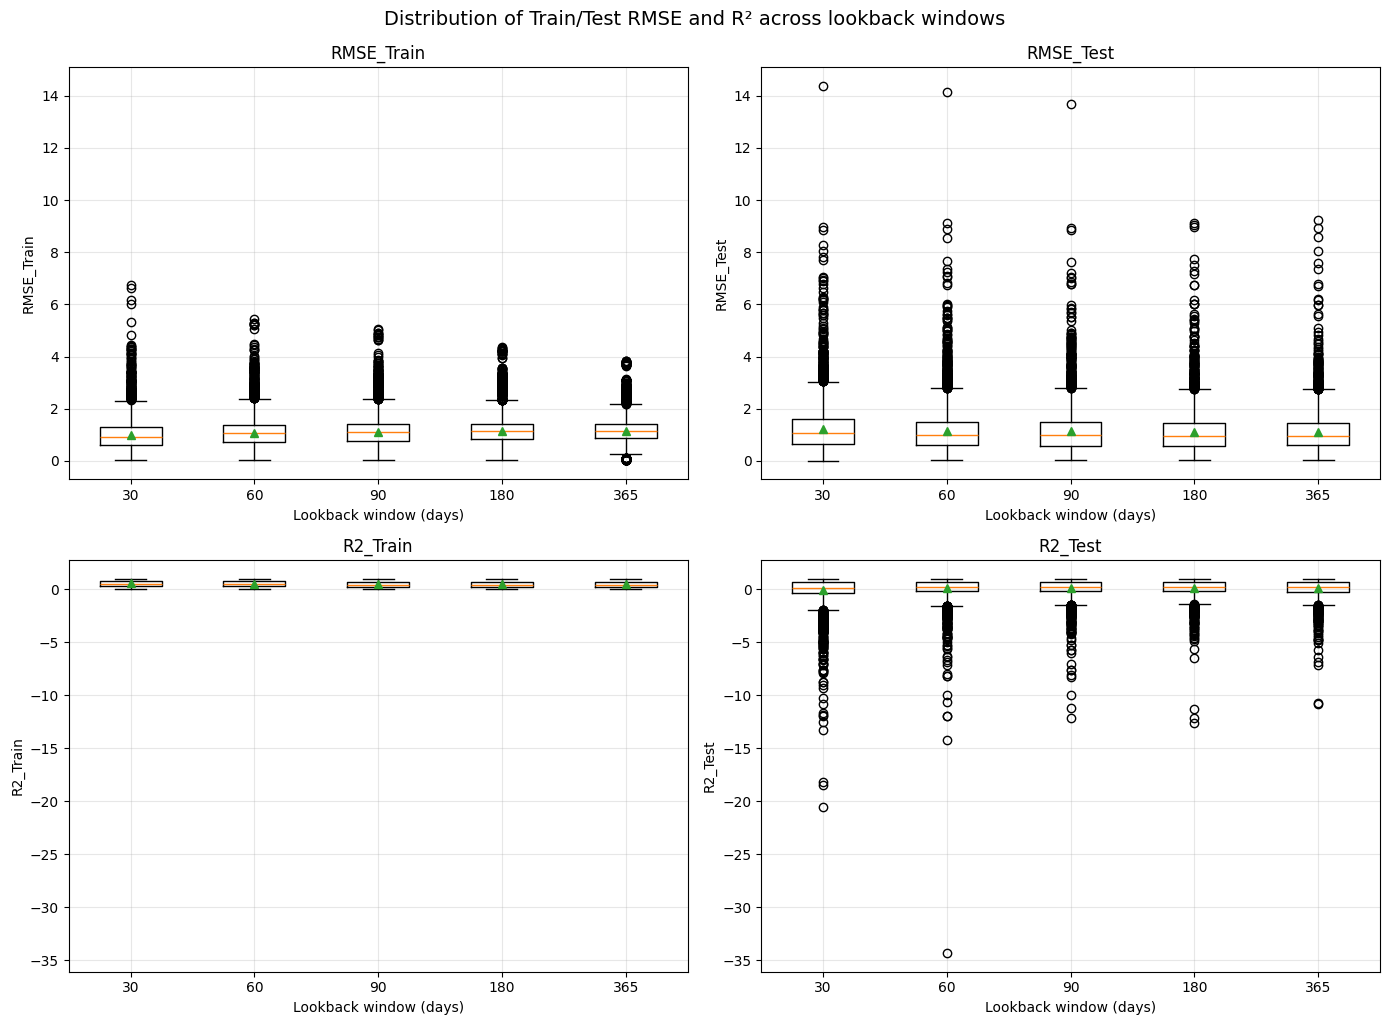

In [7]:
# Combine all fold-level results across every (ticker, lookback) into one 
all_folds = []
for (ticker, lookback), fold_df in fama_outputs.items():
    tmp = fold_df.copy()
    tmp["Ticker"] = ticker
    tmp["Lookback"] = lookback
    all_folds.append(tmp)

all_folds_df = pd.concat(all_folds, ignore_index=True)

metrics = ["RMSE_Train", "RMSE_Test", "R2_Train", "R2_Test"]

# Summary stats table per lookback window
summary = (
    all_folds_df
    .groupby("Lookback")[metrics]
    .agg(["mean", "median", "std", "min", "max", "count"])
    .round(4)
)

print("=== Summary statistics by lookback window ===")
for metric in metrics:
    print(f"\n--- {metric} ---")
    print(summary[metric])

# Distribution plots
lookback_windows_present = sorted(all_folds_df["Lookback"].unique())

# Shared y-axis ranges: one for the RMSE pair, one for the R2 pair
rmse_min = all_folds_df[["RMSE_Train", "RMSE_Test"]].min().min()
rmse_max = all_folds_df[["RMSE_Train", "RMSE_Test"]].max().max()
rmse_pad = (rmse_max - rmse_min) * 0.05

r2_min = all_folds_df[["R2_Train", "R2_Test"]].min().min()
r2_max = all_folds_df[["R2_Train", "R2_Test"]].max().max()
r2_pad = (r2_max - r2_min) * 0.05

y_ranges = {
    "RMSE_Train": (rmse_min - rmse_pad, rmse_max + rmse_pad),
    "RMSE_Test":  (rmse_min - rmse_pad, rmse_max + rmse_pad),
    "R2_Train":   (r2_min - r2_pad, r2_max + r2_pad),
    "R2_Test":    (r2_min - r2_pad, r2_max + r2_pad),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    data_by_window = [
        all_folds_df.loc[all_folds_df["Lookback"] == lb, metric].dropna()
        for lb in lookback_windows_present
    ]
    ax.boxplot(data_by_window, tick_labels=lookback_windows_present, showmeans=True)
    ax.set_title(metric)
    ax.set_xlabel("Lookback window (days)")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)
    ax.set_ylim(y_ranges[metric])

plt.tight_layout()
plt.suptitle("Distribution of Train/Test RMSE and R² across lookback windows", y=1.02, fontsize=14)
plt.show()

Results show that to maximize R2 and to minimize RMSE on the test set, we should pick a lookback window of 90. 

#### Identify best Hparams on LSTM and CNN that are trained on all ticker data
This will allow to detect how different assets move together

In [8]:
lstm_lookback_windows = [10, 20, 30, 60, 90, 180, 365]
hidden_dims = [8, 16, 32, 64, 128]

# Obtain residuals to feed into LSTM
subset_x = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

lstm_outputs = {}

In [9]:
def get_residual_series(ticker_data, fama_lookback=90, factor_forecast_span=10):
    """
    Fit rolling Fama-French models and calculate one-step-ahead residuals.

    For day t:
      1. Estimate FF coefficients using days t-fama_lookback through t-1.
      2. Forecast each FF factor for t using an EWMA through t-1.
      3. Predict the FF component of return_t using those forecast factors.
      4. Calculate residual_t = actual return_t - predicted FF return_t.
    """
    ticker_data = ticker_data.sort_values('Date').reset_index(drop=True)
    residuals = []

    for i in range(fama_lookback, len(ticker_data)):
        train = ticker_data.iloc[i - fama_lookback:i]
        current = ticker_data.iloc[[i]]

        # Fit FF model using ONLY information available before day t
        X_train = sm.add_constant(train[subset_x], has_constant='add')
        y_train = train['Daily_Excess_Return']
        model = sm.OLS(y_train, X_train).fit()

        # Forecast day-t factors using ONLY factors through day t-1
        prior_factors = ticker_data.iloc[:i][subset_x]
        forecast_factors = (
            prior_factors
            .ewm(span=factor_forecast_span, adjust=False)
            .mean()
            .iloc[-1]
        )

        # Predict day-t return using forecasted day-t factors
        X_forecast = pd.DataFrame(
            [forecast_factors],
            columns=subset_x
        )
        X_forecast = sm.add_constant(X_forecast, has_constant='add')

        pred = model.predict(X_forecast).values[0]
        actual = current['Daily_Excess_Return'].values[0]

        residuals.append({
            "Date": current['Date'].values[0],
            "Residual": actual - pred,

            # Forecast of today's factors, made using information through yesterday
            "Forecast_Mkt-RF": forecast_factors['Mkt-RF'],
            "Forecast_SMB": forecast_factors['SMB'],
            "Forecast_HML": forecast_factors['HML'],
            "Forecast_RMW": forecast_factors['RMW'],
            "Forecast_CMA": forecast_factors['CMA']
        })

    return pd.DataFrame(residuals)

In [10]:
"""
Pooled cross-sectional sequence model (LSTM or CNN) for residual return
prediction, extended to produce a next-day RISK-ADJUSTED trading signal.

KEY DESIGN DECISION:
  The deep learning model predicts the next-day FACTOR-RESIDUAL RETURN
  (mu) -- i.e. the same 'Residual' target as before. It does NOT predict
  a risk-adjusted return directly. Risk-adjustment (dividing by an
  estimate of idiosyncratic volatility) happens as a SEPARATE step:

    (A) post-hoc, using a causal rolling volatility of the residual
        (simple, no architecture change -- this is the default path), or
    (B) jointly, via a second output head that predicts log-variance,
        trained with a Gaussian NLL loss, so mu and sigma come from the
        same forward pass (opt-in via model_type='lstm_hetero' or
        'cnn_hetero').

  Either way you end up with mu (expected residual) AND sigma (expected
  vol) as separate quantities. That's what Kelly / vol-targeting position
  sizing needs (f* ~ mu / sigma^2 requires mean and variance separately).
  Training the network directly on an already-divided "risk-adjusted
  return" target throws that decomposition away and is numerically
  unstable (dividing by near-zero rolling vol on quiet days blows up the
  label).

  The actual trading signal you rank/threshold on is:
      risk_adjusted_signal = mu / sigma
  computed in `risk_adjusted_signal()` below, and returned per-row in the
  'Signals' DataFrame from `train_pooled_model()`.

WHAT CHANGED FROM THE ORIGINAL SKELETON:
  1. add_rolling_vol()                     -- new (path A)
  2. make_sequences(..., extra_cols=...)   -- extended to carry through
                                               unscaled columns (vol,
                                               date, ticker) aligned to
                                               the last known day, so
                                               nothing has to be
                                               re-joined by index later
  3. PooledLSTM / PooledCNN                -- unchanged
  4. PooledLSTMHetero / PooledCNNHetero    -- new (path B, opt-in)
  5. gaussian_nll_loss()                   -- new
  6. risk_adjusted_signal(), compute_rank_ic()  -- new
  7. train_pooled_model()                  -- branches on hetero vs.
                                               plain models, returns a
                                               'Signals' DataFrame with
                                               Pred_Residual, Vol_Estimate,
                                               Risk_Adjusted_Signal per
                                               (Date, Ticker) in the test
                                               set
  8. run_pooled_grid_search()              -- calls add_rolling_vol(),
                                               reports Mean_Rank_IC,
                                               returns the best config's
                                               signals directly
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler


# ---------------------------------------------------------------------------
# 1. Build per-ticker frames (unchanged from original)
# ---------------------------------------------------------------------------

def build_all_ticker_frames(dfs, subset_x, fama_lookback=90):
    """
    Runs your existing per-ticker preprocessing (daily aggregation, rolling
    Fama-French residuals, forecast-shift, feature assembly) and returns a
    dict {ticker: model_input_df}.
    """
    ohlcv_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    frames = {}

    for ticker in dfs['1d']['Ticker'].unique():
        raw_ticker_data = dfs['1d'][dfs['1d']['Ticker'] == ticker].sort_values('Datetime')
        has_splits = 'Stock Splits' in raw_ticker_data.columns

        agg_dict = {'Open': 'first', 'High': 'max', 'Low': 'min',
                    'Close': 'last', 'Volume': 'sum'}
        if has_splits:
            agg_dict['Stock Splits'] = 'sum'

        daily_ohlcv = raw_ticker_data.groupby('Date').agg(agg_dict).reset_index()

        ticker_data = raw_ticker_data.dropna(subset=subset_x)
        ticker_data = (
            ticker_data[['Date', 'Daily_Excess_Return'] + subset_x]
            .drop_duplicates()
            .sort_values('Date')
        )

        residual_df = get_residual_series(ticker_data, fama_lookback=fama_lookback)  # noqa: F821
        if residual_df.empty:
            print(f"[SKIP] {ticker}: not enough data for residuals")
            continue

        model_input = (
            residual_df
            .merge(daily_ohlcv, on='Date', how='inner')
            .merge(ticker_data[['Date'] + subset_x], on='Date', how='inner')
            .sort_values('Date')
            .reset_index(drop=True)
        )

        forecast_cols = [f"Forecast_{factor}" for factor in subset_x]
        for col in forecast_cols:
            model_input[f"Next_{col}"] = model_input[col].shift(-1)

        feature_cols = (
            ['Residual'] + ohlcv_cols + subset_x
            + [f"Next_Forecast_{factor}" for factor in subset_x]
            + (['Stock Splits'] if has_splits else [])
        )

        model_input[feature_cols] = model_input[feature_cols].apply(pd.to_numeric, errors='coerce')
        model_input = model_input.dropna(subset=feature_cols).reset_index(drop=True)

        model_input['Ticker'] = ticker
        frames[ticker] = model_input

    return frames


# ---------------------------------------------------------------------------
# 2. Concatenate into one panel (unchanged)
# ---------------------------------------------------------------------------

def build_panel(frames: dict, feature_cols: list, target_col: str = 'Residual'):
    """
    Concatenates all per-ticker frames into one long panel, sorted by
    Ticker then Date. Target = next-day residual, shifted WITHIN each
    ticker group (no cross-ticker leakage).
    """
    panel = pd.concat(frames.values(), ignore_index=True)
    panel = panel.sort_values(['Ticker', 'Date']).reset_index(drop=True)

    panel['Target'] = panel.groupby('Ticker')[target_col].shift(-1)
    panel = panel.dropna(subset=['Target'] + feature_cols).reset_index(drop=True)

    tickers = sorted(panel['Ticker'].unique())
    ticker_to_id = {t: i for i, t in enumerate(tickers)}
    panel['TickerID'] = panel['Ticker'].map(ticker_to_id)

    return panel, ticker_to_id


def add_rolling_vol(panel: pd.DataFrame, vol_window: int = 20,
                     target_col: str = 'Residual', min_periods: int = None):
    """
    Causal (backward-looking) rolling std of the residual, per ticker.

    This is NOT a model input feature -- it's carried through separately
    and used post-hoc (path A) to convert a predicted residual into a
    risk-adjusted signal: pred_residual / Residual_Vol. Because
    make_sequences() pulls extra_cols from the LAST row of each lookback
    window (i.e. one day before the target day), the vol estimate used at
    inference is always known as-of the prediction date -- no lookahead.
    """
    panel = panel.sort_values(['Ticker', 'Date']).copy()
    min_periods = min_periods or max(2, vol_window // 2)
    panel['Residual_Vol'] = (
        panel.groupby('Ticker')[target_col]
             .transform(lambda s: s.rolling(vol_window, min_periods=min_periods).std())
    )
    return panel


# ---------------------------------------------------------------------------
# 3. Global date-based split (unchanged)
# ---------------------------------------------------------------------------

def time_split(panel: pd.DataFrame, train_end: str, val_end: str):
    train = panel[panel['Date'] <= train_end]
    val = panel[(panel['Date'] > train_end) & (panel['Date'] <= val_end)]
    test = panel[panel['Date'] > val_end]
    return train, val, test


# ---------------------------------------------------------------------------
# 4. Windowing -- extended with extra_cols for post-hoc use
# ---------------------------------------------------------------------------

def make_sequences(df: pd.DataFrame, feature_cols: list, lookback: int,
                    extra_cols: list = None,
                    pad_short_sequences: bool = False,
                    pad_value: float = 0.0):
    """
    Builds (X, y, ticker_id, extras) sequences. Windows are built
    per-ticker group so a sequence never mixes rows from two different
    tickers, even though the underlying df is pooled and sorted by
    Ticker+Date.

    extra_cols: columns carried through UNSCALED, aligned to the LAST row
    of each window (index i-1 -- the most recent day known at prediction
    time, one day before the target). Use this for 'Residual_Vol' (risk
    adjustment), or 'Date'/'Ticker' (bookkeeping when generating trade
    signals) -- avoids re-joining by row index later, which is easy to
    get misaligned.

    pad_short_sequences: if False (default), a ticker/split with fewer
    than `lookback` rows is dropped entirely -- original behavior. If
    True, its feature sequence is front-padded with `pad_value` instead,
    so a window can still be built for every real target day. The
    earliest usable target is always index 1, never index 0: a window
    built from 100% padding carries no information, and index 0 has no
    real prior day for extra_cols (e.g. Residual_Vol) to point to.

    pad_value: fill value for padded rows, in the SAME units as
    feature_cols. This function is called AFTER StandardScaler in
    train_pooled_model, so feature_cols are already zero-mean -- the
    default pad_value=0.0 is therefore "pad with the training-set mean",
    a neutral value chosen not to bias the LSTM's hidden state in either
    direction. If you call this on unscaled data, pick pad_value
    accordingly (or scale first).
    """
    extra_cols = extra_cols or []
    X_list, y_list, tid_list = [], [], []
    extra_lists = {c: [] for c in extra_cols}

    for tid, g in df.groupby('TickerID'):
        g = g.sort_values('Date')
        feats = g[feature_cols].values
        targets = g['Target'].values
        extras = {c: g[c].values for c in extra_cols}
        n = len(g)

        if n < 2:
            continue  # need at least 1 real history day + 1 target day

        if n <= lookback:
            if not pad_short_sequences:
                continue  # original behavior: drop this ticker/split
            pad_block = np.full((lookback, feats.shape[1]), pad_value, dtype=feats.dtype)
            feats_padded = np.vstack([pad_block, feats])  # shape (lookback + n, n_features)
            window_fn = lambda i: feats_padded[i: i + lookback]  # noqa: E731
            i_range = range(1, n)
        else:
            window_fn = lambda i: feats[i - lookback: i]  # noqa: E731
            i_range = range(lookback, n)

        for i in i_range:
            X_list.append(window_fn(i))
            y_list.append(targets[i])
            tid_list.append(tid)
            for c in extra_cols:
                extra_lists[c].append(extras[c][i - 1])

    X = np.stack(X_list) if X_list else np.empty((0, lookback, len(feature_cols)))
    y = np.array(y_list)
    tid = np.array(tid_list)
    extras_out = {c: np.array(v) for c, v in extra_lists.items()}
    return X, y, tid, extras_out


class SequenceDataset(Dataset):
    def __init__(self, X, y, tid):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.tid = torch.tensor(tid, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.tid[idx], self.y[idx]


# ---------------------------------------------------------------------------
# 5. Models
#    - PooledLSTM / PooledCNN: single output (mu), unchanged from original
#    - *Hetero variants: two outputs (mu, logvar), path B
# ---------------------------------------------------------------------------

class PooledLSTM(nn.Module):
    def __init__(self, n_features, hidden_dim, n_tickers, ticker_emb_dim=4, dropout=0.2):
        super().__init__()
        self.ticker_emb = nn.Embedding(n_tickers, ticker_emb_dim)
        self.lstm = nn.LSTM(n_features, hidden_dim, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_dim + ticker_emb_dim, 1)

    def forward(self, x, tid):
        _, (h_n, _) = self.lstm(x)
        h_last = h_n[-1]
        emb = self.ticker_emb(tid)
        out = self.dropout(torch.cat([h_last, emb], dim=1))
        return self.head(out).squeeze(-1)


class PooledCNN(nn.Module):
    def __init__(self, n_features, hidden_dim, n_tickers, ticker_emb_dim=4, dropout=0.2):
        super().__init__()
        self.ticker_emb = nn.Embedding(n_tickers, ticker_emb_dim)
        self.conv = nn.Sequential(
            nn.Conv1d(n_features, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_dim + ticker_emb_dim, 1)

    def forward(self, x, tid):
        x = x.transpose(1, 2)
        h = self.pool(self.conv(x)).squeeze(-1)
        emb = self.ticker_emb(tid)
        out = self.dropout(torch.cat([h, emb], dim=1))
        return self.head(out).squeeze(-1)


class PooledLSTMHetero(nn.Module):
    """
    Same backbone as PooledLSTM but with two heads: predicted mean (mu)
    and predicted log-variance (logvar) of the next-day residual. Trained
    with Gaussian NLL, so mu / exp(0.5*logvar) is a risk-adjusted signal
    that comes straight out of the model instead of a separate rolling-vol
    estimate.
    """
    def __init__(self, n_features, hidden_dim, n_tickers, ticker_emb_dim=4, dropout=0.2):
        super().__init__()
        self.ticker_emb = nn.Embedding(n_tickers, ticker_emb_dim)
        self.lstm = nn.LSTM(n_features, hidden_dim, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.mu_head = nn.Linear(hidden_dim + ticker_emb_dim, 1)
        self.logvar_head = nn.Linear(hidden_dim + ticker_emb_dim, 1)

    def forward(self, x, tid):
        _, (h_n, _) = self.lstm(x)
        h_last = h_n[-1]
        emb = self.ticker_emb(tid)
        out = self.dropout(torch.cat([h_last, emb], dim=1))
        mu = self.mu_head(out).squeeze(-1)
        logvar = self.logvar_head(out).squeeze(-1)
        return mu, logvar


class PooledCNNHetero(nn.Module):
    def __init__(self, n_features, hidden_dim, n_tickers, ticker_emb_dim=4, dropout=0.2):
        super().__init__()
        self.ticker_emb = nn.Embedding(n_tickers, ticker_emb_dim)
        self.conv = nn.Sequential(
            nn.Conv1d(n_features, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.mu_head = nn.Linear(hidden_dim + ticker_emb_dim, 1)
        self.logvar_head = nn.Linear(hidden_dim + ticker_emb_dim, 1)

    def forward(self, x, tid):
        x = x.transpose(1, 2)
        h = self.pool(self.conv(x)).squeeze(-1)
        emb = self.ticker_emb(tid)
        out = self.dropout(torch.cat([h, emb], dim=1))
        mu = self.mu_head(out).squeeze(-1)
        logvar = self.logvar_head(out).squeeze(-1)
        return mu, logvar


def gaussian_nll_loss(mu, logvar, target, logvar_clamp=(-10.0, 10.0)):
    """
    Negative log-likelihood of target under N(mu, exp(logvar)). Clamping
    logvar avoids the classic heteroskedastic-head failure mode where the
    model drives predicted variance to ~0 or ~inf to game the loss on a
    handful of points.
    """
    logvar = logvar.clamp(*logvar_clamp)
    return (0.5 * logvar + 0.5 * (target - mu) ** 2 / logvar.exp()).mean()


# ---------------------------------------------------------------------------
# 6. Risk-adjustment + signal-quality helpers
# ---------------------------------------------------------------------------

def risk_adjusted_signal(pred_mu, vol_estimate, eps=1e-6, clip_at=5.0):
    """
    Converts a predicted residual (mu) into a risk-adjusted trading
    signal: mu / vol. This is what you rank/threshold on for execution,
    and what you'd feed (raw, or its mu/vol components) into the PPO
    position sizer as state features.

    vol_estimate: either rolling Residual_Vol (path A) or
    exp(0.5*logvar) from a hetero model (path B).

    clip_at: caps the signal so a handful of near-zero-vol days (which
    blow up the ratio) don't dominate downstream ranking/sizing.
    """
    signal = pred_mu / (vol_estimate + eps)
    if clip_at is not None:
        signal = np.clip(signal, -clip_at, clip_at)
    return signal


def compute_rank_ic(signals_df: pd.DataFrame,
                     pred_col: str = 'Pred_Residual',
                     actual_col: str = 'Actual_Residual',
                     date_col: str = 'Date') -> pd.Series:
    """
    Daily cross-sectional rank correlation ("Rank IC") between predicted
    and actual residuals -- the standard stat-arb signal-quality metric,
    since what matters for trade selection is whether tickers are ranked
    correctly each day, not point-wise RMSE. Implemented as Pearson
    correlation of within-day ranks (== Spearman's rho), so no scipy
    dependency is required.
    """
    def _ic(g):
        if len(g) < 3:
            return np.nan
        return g[pred_col].rank().corr(g[actual_col].rank())

    # Select only the columns _ic needs before grouping, so date_col
    # itself isn't part of what gets passed to apply(). This avoids
    # pandas' FutureWarning about grouping-column behavior and works
    # across pandas versions (no dependency on the include_groups= kwarg,
    # which only exists from pandas 2.2 onward).
    return (
        signals_df.groupby(date_col)[[pred_col, actual_col]]
        .apply(_ic)
        .rename('Rank_IC')
    )


# ---------------------------------------------------------------------------
# 7. Train / evaluate one config on the pooled panel
# ---------------------------------------------------------------------------

_MODEL_CLASSES = {
    'lstm': PooledLSTM,
    'cnn': PooledCNN,
    'lstm_hetero': PooledLSTMHetero,
    'cnn_hetero': PooledCNNHetero,
}


def _eval_rmse(model, loader, device, is_hetero=False):
    model.eval()
    sq_errors, n = 0.0, 0
    with torch.no_grad():
        for xb, tidb, yb in loader:
            xb, tidb, yb = xb.to(device), tidb.to(device), yb.to(device)
            pred = model(xb, tidb)[0] if is_hetero else model(xb, tidb)
            sq_errors += ((pred - yb) ** 2).sum().item()
            n += len(yb)
    return float(np.sqrt(sq_errors / n)) if n else float('nan')


def train_pooled_model(
    panel, feature_cols, ticker_to_id,
    lookback, hidden_dim, model_type='lstm',
    train_end='2023-12-31', val_end='2024-12-31',
    epochs=50, batch_size=256, lr=1e-3, patience=5, device=None,
    vol_col='Residual_Vol', signal_clip=5.0,
    pad_short_sequences=False, pad_value=0.0,
):
    """
    model_type: 'lstm' / 'cnn' (predict mu only, MSE loss -- path A risk
    adjustment happens post-hoc using vol_col) or 'lstm_hetero' /
    'cnn_hetero' (predict mu AND logvar jointly, Gaussian NLL loss --
    path B risk adjustment uses the model's own vol estimate).

    pad_short_sequences / pad_value: passed straight through to
    make_sequences() for all three splits -- see that docstring. Off by
    default, so behavior is unchanged unless you opt in.

    Returns a results dict including a 'Signals' DataFrame: one row per
    (Date, Ticker) in the test set with Pred_Residual, Vol_Estimate, and
    Risk_Adjusted_Signal -- this is what you'd rank/threshold to pick
    trades, and what Mean_Rank_IC is computed from.
    """
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    is_hetero = model_type.endswith('_hetero')

    train_df, val_df, test_df = time_split(panel, train_end, val_end)

    scaler = StandardScaler()
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    val_df[feature_cols] = scaler.transform(val_df[feature_cols])
    test_df[feature_cols] = scaler.transform(test_df[feature_cols])

    X_tr, y_tr, tid_tr, _ = make_sequences(
        train_df, feature_cols, lookback,
        pad_short_sequences=pad_short_sequences, pad_value=pad_value)
    X_val, y_val, tid_val, _ = make_sequences(
        val_df, feature_cols, lookback,
        pad_short_sequences=pad_short_sequences, pad_value=pad_value)

    test_extra_cols = ['Date', 'Ticker'] + ([vol_col] if vol_col in test_df.columns else [])
    X_te, y_te, tid_te, extras_te = make_sequences(
        test_df, feature_cols, lookback, extra_cols=test_extra_cols,
        pad_short_sequences=pad_short_sequences, pad_value=pad_value)

    if len(y_tr) == 0 or len(y_val) == 0:
        return None

    train_loader = DataLoader(SequenceDataset(X_tr, y_tr, tid_tr), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SequenceDataset(X_val, y_val, tid_val), batch_size=batch_size, shuffle=False)

    n_features = len(feature_cols)
    n_tickers = len(ticker_to_id)
    model = _MODEL_CLASSES[model_type](n_features, hidden_dim, n_tickers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_rmse = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        for xb, tidb, yb in train_loader:
            xb, tidb, yb = xb.to(device), tidb.to(device), yb.to(device)
            optimizer.zero_grad()
            if is_hetero:
                mu, logvar = model(xb, tidb)
                loss = gaussian_nll_loss(mu, logvar, yb)
            else:
                pred = model(xb, tidb)
                loss = nn.functional.mse_loss(pred, yb)
            loss.backward()
            optimizer.step()

        val_rmse = _eval_rmse(model, val_loader, device, is_hetero)
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    train_rmse = _eval_rmse(model, train_loader, device, is_hetero)

    # Test-set predictions + risk-adjusted signal.
    model.eval()
    vol_pred = None
    with torch.no_grad():
        xb = torch.tensor(X_te, dtype=torch.float32).to(device)
        tidb = torch.tensor(tid_te, dtype=torch.long).to(device)
        if is_hetero:
            mu, logvar = model(xb, tidb)
            mu = mu.cpu().numpy()
            vol_pred = np.exp(0.5 * logvar.clamp(-10, 10).cpu().numpy())
        else:
            mu = model(xb, tidb).cpu().numpy()
            vol_pred = extras_te.get(vol_col)

    test_rmse = float(np.sqrt(np.mean((mu - y_te) ** 2))) if len(y_te) else float('nan')

    signals_df = pd.DataFrame({
        'Date': extras_te['Date'],
        'Ticker': extras_te['Ticker'],
        'Pred_Residual': mu,
        'Actual_Residual': y_te,
    })
    if vol_pred is not None:
        signals_df['Vol_Estimate'] = vol_pred
        signals_df['Risk_Adjusted_Signal'] = risk_adjusted_signal(mu, vol_pred, clip_at=signal_clip)

    mean_rank_ic = compute_rank_ic(signals_df).mean() if len(signals_df) else float('nan')

    return {
        'Lookback': lookback,
        'Hidden_Dim': hidden_dim,
        'Model_Type': model_type,
        'RMSE_Train': train_rmse,
        'RMSE_Val': best_val_rmse,
        'RMSE_Test': test_rmse,
        'Mean_Rank_IC': mean_rank_ic,
        'N_Train': len(y_tr),
        'N_Val': len(y_val),
        'N_Test': len(y_te),
        'Signals': signals_df,
    }


# ---------------------------------------------------------------------------
# 8. Full driver: hyperparameter grid over (lookback x hidden_dim x model_type)
# ---------------------------------------------------------------------------

def run_pooled_grid_search(dfs, subset_x, lookback_windows, hidden_dims,
                            model_types=('lstm', 'cnn'),
                            train_end='2023-12-31', val_end='2024-12-31',
                            vol_window=20):
    """
    model_types can mix plain and hetero variants, e.g.
    ('lstm', 'lstm_hetero', 'cnn') to compare path A vs. path B directly
    on Mean_Rank_IC.
    """
    frames = build_all_ticker_frames(dfs, subset_x)

    ohlcv_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    feature_cols = (
        ['Residual'] + ohlcv_cols + subset_x
        + [f"Next_Forecast_{factor}" for factor in subset_x]
    )
    # NOTE: drop 'Stock Splits' from the shared feature list unless every
    # ticker's frame has it -- pooled panel needs a consistent column set.

    panel, ticker_to_id = build_panel(frames, feature_cols)
    panel = add_rolling_vol(panel, vol_window=vol_window)  # enables risk-adjusted signal

    results = []
    for model_type in model_types:
        for lb in lookback_windows:
            for hd in hidden_dims:
                res = train_pooled_model(
                    panel, feature_cols, ticker_to_id,
                    lookback=lb, hidden_dim=hd, model_type=model_type,
                    train_end=train_end, val_end=val_end,
                )
                if res is not None:
                    results.append(res)
                    print(f"model={model_type}, lookback={lb}, hidden_dim={hd} "
                          f"-> val_rmse={res['RMSE_Val']:.4f}, test_rmse={res['RMSE_Test']:.4f}, "
                          f"mean_rank_ic={res['Mean_Rank_IC']:.4f}")
                else:
                    print(f"[SKIP] model={model_type}, lookback={lb}, hidden_dim={hd}: not enough data")

    results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'Signals'} for r in results])
    best_pos = results_df['RMSE_Val'].idxmin()
    best_model_row = results_df.loc[best_pos]
    best_signals = results[best_pos]['Signals']

    return results_df, best_model_row, best_signals, panel, ticker_to_id


# ---------------------------------------------------------------------------
# Example usage:
#
# results_df, best_model, best_signals, panel, ticker_to_id = run_pooled_grid_search(
#     dfs, subset_x,
#     lookback_windows=[10, 20, 30, 60, 90],
#     hidden_dims=[16, 32, 64],
#     model_types=('lstm', 'lstm_hetero', 'cnn'),   # compare path A vs. path B
#     train_end='2023-12-31',
#     val_end='2024-12-31',
# )
# print(results_df.sort_values('RMSE_Val').head(10))
# print(best_model)
#
# # best_signals: one row per (Date, Ticker) in the test set
# print(best_signals.sort_values('Date').tail())
#
# # Cross-sectionally rank today's signal to pick a long/short basket:
# latest_day = best_signals['Date'].max()
# today = best_signals[best_signals['Date'] == latest_day].copy()
# today['Rank_Pct'] = today['Risk_Adjusted_Signal'].rank(pct=True)
# longs = today.sort_values('Risk_Adjusted_Signal', ascending=False).head(5)
# shorts = today.sort_values('Risk_Adjusted_Signal').head(5)
#
# # Feed Pred_Residual and Vol_Estimate (not the pre-divided ratio) into
# # your PPO position sizer as separate state features, so it can learn
# # its own mean/variance trade-off rather than inheriting a fixed one.
# ---------------------------------------------------------------------------

In [11]:
results_df, best_model, best_signals, panel, ticker_to_id = run_pooled_grid_search(
    dfs, subset_x,
    lookback_windows = [10, 20, 30, 60, 90, 180, 365],
    hidden_dims = [8, 16, 32, 64, 128],
    model_types=('lstm', 'lstm_hetero', 'cnn'),   # compare path A vs. path B
    train_end='2023-12-31',
    val_end='2024-12-31',
)
print(results_df.sort_values('RMSE_Val').head(10))
print(best_model)

# best_signals: one row per (Date, Ticker) in the test set
print(best_signals.sort_values('Date').tail())

# Cross-sectionally rank today's signal to pick a long/short basket:
latest_day = best_signals['Date'].max()
today = best_signals[best_signals['Date'] == latest_day].copy()
today['Rank_Pct'] = today['Risk_Adjusted_Signal'].rank(pct=True)
longs = today.sort_values('Risk_Adjusted_Signal', ascending=False).head(5)
shorts = today.sort_values('Risk_Adjusted_Signal').head(5)

model=lstm, lookback=10, hidden_dim=8 -> val_rmse=1.5742, test_rmse=1.9592, mean_rank_ic=0.0090
model=lstm, lookback=10, hidden_dim=16 -> val_rmse=1.5731, test_rmse=1.9565, mean_rank_ic=0.0014
model=lstm, lookback=10, hidden_dim=32 -> val_rmse=1.5689, test_rmse=1.9558, mean_rank_ic=0.0050
model=lstm, lookback=10, hidden_dim=64 -> val_rmse=1.5729, test_rmse=1.9531, mean_rank_ic=0.0064
model=lstm, lookback=10, hidden_dim=128 -> val_rmse=1.5728, test_rmse=1.9555, mean_rank_ic=0.0017
model=lstm, lookback=20, hidden_dim=8 -> val_rmse=1.5818, test_rmse=1.9464, mean_rank_ic=0.0354
model=lstm, lookback=20, hidden_dim=16 -> val_rmse=1.5833, test_rmse=1.9532, mean_rank_ic=0.0156
model=lstm, lookback=20, hidden_dim=32 -> val_rmse=1.5772, test_rmse=1.9426, mean_rank_ic=-0.0017
model=lstm, lookback=20, hidden_dim=64 -> val_rmse=1.5806, test_rmse=1.9456, mean_rank_ic=0.0012
model=lstm, lookback=20, hidden_dim=128 -> val_rmse=1.5787, test_rmse=1.9398, mean_rank_ic=0.0029
model=lstm, lookback=30, hidd

KeyboardInterrupt: 

#### Positioning Logic

In [ ]:
"""
Turns a predicted residual into a position, backtests it, and sets up the
two benchmarks:

  (a) Factor-residual LSTM vs. raw-price LSTM baseline
      -- does Fama-French residualization before prediction actually
      help, or would the same architecture do just as well predicting
      raw next-day returns directly?

  (b) RL-based (PPO) position allocator vs. non-blackbox baselines
      (Kelly criterion, volatility targeting)
      -- does letting an RL agent decide position size beat simple
      closed-form sizing rules operating on the SAME signal?

CORE MODELING ASSUMPTION (applies to every Sharpe/MDD number this module
produces):
    portfolio_return_t = sum_i  position_weight_i,t * realized_i,t

  For the factor-residual pipeline, realized_i,t = Actual_Residual --
  this is only the P&L you'd actually earn if the position is
  factor-hedged (e.g. long the stock, short its factor exposure). If your
  execution can't hedge that out (no shorting the factor legs,
  transaction costs on the hedge, etc.), this OVERSTATES achievable
  Sharpe -- say so explicitly whenever you report these numbers.

  For the raw-price baseline, realized_i,t = Actual_Residual too, but
  that column holds RAW RETURN there (see run_raw_price_baseline docs),
  so its backtest carries real, unhedged market beta. The two Sharpes
  are therefore not directly comparable as "market-neutral vs.
  market-neutral" -- the raw baseline's number already includes beta
  risk the residual pipeline was specifically built to strip out.
"""

# ---------------------------------------------------------------------------
# 1. Position sizing rules (non-blackbox baselines for the RL allocator)
# ---------------------------------------------------------------------------

def kelly_position_size(mu, sigma, kelly_fraction=0.5, max_abs_position=2.0, eps=1e-6):
    """
    Growth-optimal (Kelly) position size assuming the residual is
    approximately N(mu, sigma^2): f* = mu / sigma^2.

    kelly_fraction: scales full Kelly down (0.5 = "half Kelly"). Full
    Kelly is extremely sensitive to estimation error in mu/sigma -- a
    slightly-off variance estimate can blow the position up -- so
    fractional Kelly (0.25-0.5) is standard practice, not a compromise.

    max_abs_position: hard cap so one noisy, near-zero-sigma estimate
    can't dominate the whole book.
    """
    raw = mu / (sigma ** 2 + eps)
    sized = kelly_fraction * raw
    return np.clip(sized, -max_abs_position, max_abs_position)


def vol_target_position_size(mu, sigma, target_vol=0.01, max_abs_position=2.0, eps=1e-6):
    """
    Sizes purely to hit a target daily volatility contribution per
    position: direction = sign(mu), magnitude = target_vol / sigma.

    Unlike Kelly, this ignores the STRENGTH of the predicted return --
    a strategy that spends the same risk budget on every position
    regardless of conviction. Useful as a baseline that isolates how
    much of Kelly's edge (if any) comes from magnitude-weighting rather
    than just getting direction right.
    """
    direction = np.sign(mu)
    sized = direction * target_vol / (sigma + eps)
    return np.clip(sized, -max_abs_position, max_abs_position)


# ---------------------------------------------------------------------------
# 2. Backtest engine
# ---------------------------------------------------------------------------

def normalize_daily_weights(signals_df, position_col, target_gross=1.0, date_col='Date'):
    """
    Rescales each day's raw position sizes so gross exposure
    (sum of |weight|) equals `target_gross`.

    Without this, Kelly and vol-targeting produce very different total
    leverage by construction (Kelly can size up hard on a strong,
    low-vol signal; vol-targeting never does), which would confound a
    Sharpe/drawdown comparison -- you'd partly be comparing "how much
    risk did each strategy take" rather than "how good was the signal
    net of sizing." Normalizing gross exposure isolates the latter.
    """
    df = signals_df.copy()
    gross = df.groupby(date_col)[position_col].transform(lambda w: w.abs().sum())
    df[position_col + '_norm'] = np.where(
        gross > 0, df[position_col] / gross * target_gross, 0.0
    )
    return df


def run_backtest(signals_df, position_col, actual_col='Actual_Residual',
                  date_col='Date', target_gross=1.0):
    """
    Converts a per-(Date, Ticker) position column into a daily portfolio
    return series: normalize gross exposure per day, then
        return_t = sum_i weight_i,t * actual_col_i,t

    See module docstring for the factor-hedging assumption this implies.
    """
    df = normalize_daily_weights(signals_df, position_col, target_gross, date_col)
    weight_col = position_col + '_norm'
    df['_pnl'] = df[weight_col] * df[actual_col]
    daily_returns = df.groupby(date_col)['_pnl'].sum().sort_index()
    daily_returns.index.name = date_col
    return daily_returns


def sharpe_ratio(daily_returns, periods_per_year=252, rf_daily=0.0):
    excess = daily_returns - rf_daily
    if len(excess) < 2 or excess.std(ddof=1) == 0:
        return float('nan')
    return float(excess.mean() / excess.std(ddof=1) * np.sqrt(periods_per_year))


def max_drawdown(daily_returns):
    """
    Max peak-to-trough decline of the compounded equity curve, as a
    negative fraction (e.g. -0.23 = a 23% drawdown).
    """
    if len(daily_returns) == 0:
        return float('nan')
    equity = (1.0 + daily_returns).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    return float(drawdown.min())


def evaluate_backtest(daily_returns, periods_per_year=252):
    return {
        'Sharpe': sharpe_ratio(daily_returns, periods_per_year),
        'Max_Drawdown': max_drawdown(daily_returns),
        'Ann_Return': float(daily_returns.mean() * periods_per_year) if len(daily_returns) else float('nan'),
        'Ann_Vol': float(daily_returns.std(ddof=1) * np.sqrt(periods_per_year)) if len(daily_returns) > 1 else float('nan'),
        'N_Days': int(len(daily_returns)),
    }


# ---------------------------------------------------------------------------
# 3. RL (PPO) vs. Kelly vs. vol-targeting, on identical footing
# ---------------------------------------------------------------------------

def compare_position_sizing(signals_df, sizing_configs, actual_col='Actual_Residual',
                             date_col='Date', target_gross=1.0):
    """
    sizing_configs: dict {name: (position_fn, kwargs)}, e.g.
        {
          'Kelly (0.5x)':   (kelly_position_size, {'kelly_fraction': 0.5}),
          'Vol-Target 1%':  (vol_target_position_size, {'target_vol': 0.01}),
        }
    position_fn must accept (mu_array, sigma_array, **kwargs) and return
    an array of position sizes -- kelly_position_size and
    vol_target_position_size both match this signature.

    To add your PPO agent to the same table: put its output position
    weights directly into a column on signals_df (it's already a sizer,
    not a signal needing conversion), then call run_backtest /
    evaluate_backtest on that column and append the result -- there's no
    position_fn step for it, since the RL policy IS the sizing function.
    """
    rows = []
    df = signals_df.copy()
    for name, (fn, kwargs) in sizing_configs.items():
        col = f'_pos_{name}'
        df[col] = fn(df['Pred_Residual'].values, df['Vol_Estimate'].values, **kwargs)
        daily_returns = run_backtest(df, col, actual_col, date_col, target_gross)
        metrics = evaluate_backtest(daily_returns)
        metrics['Strategy'] = name
        rows.append(metrics)

    return pd.DataFrame(rows).set_index('Strategy')[
        ['Sharpe', 'Max_Drawdown', 'Ann_Return', 'Ann_Vol', 'N_Days']
    ]


def add_ppo_to_comparison(comparison_df, ppo_daily_returns, name='PPO Allocator',
                           periods_per_year=252):
    """
    Appends an already-backtested PPO daily-return series (e.g. from
    your own env's rollout, not run_backtest -- the RL agent's reward
    trajectory already IS the daily return series) to a
    compare_position_sizing() table for a single side-by-side view.
    """
    metrics = evaluate_backtest(ppo_daily_returns, periods_per_year)
    metrics['Strategy'] = name
    row = pd.DataFrame([metrics]).set_index('Strategy')[
        ['Sharpe', 'Max_Drawdown', 'Ann_Return', 'Ann_Vol', 'N_Days']
    ]
    return pd.concat([comparison_df, row])


# ---------------------------------------------------------------------------
# 4. Raw-price LSTM baseline (for the residual-vs-raw comparison)
# ---------------------------------------------------------------------------

def build_all_ticker_frames_raw(dfs, ohlcv_cols=None):
    """
    Raw-price counterpart to build_all_ticker_frames(): same daily OHLCV
    aggregation, but NO Fama-French regression at all. Target is next-day
    raw return; features are OHLCV only -- no factor-derived columns.

    This is the baseline for "does residualizing actually help": same
    pooled architecture, same training procedure, same evaluation
    (Rank IC, backtest Sharpe/MDD) as the factor-residual pipeline --
    the ONLY thing that changes is what the model predicts and what
    it's allowed to see.
    """
    ohlcv_cols = ohlcv_cols or ['Open', 'High', 'Low', 'Close', 'Volume']
    frames = {}

    for ticker in dfs['1d']['Ticker'].unique():
        raw_ticker_data = dfs['1d'][dfs['1d']['Ticker'] == ticker].sort_values('Datetime')
        has_splits = 'Stock Splits' in raw_ticker_data.columns

        agg_dict = {'Open': 'first', 'High': 'max', 'Low': 'min',
                    'Close': 'last', 'Volume': 'sum'}
        if has_splits:
            agg_dict['Stock Splits'] = 'sum'

        daily_ohlcv = (
            raw_ticker_data.groupby('Date').agg(agg_dict).reset_index().sort_values('Date')
        )
        daily_ohlcv['Raw_Return'] = daily_ohlcv['Close'].pct_change()
        daily_ohlcv = daily_ohlcv.dropna(subset=['Raw_Return']).reset_index(drop=True)

        feature_cols = ohlcv_cols + (['Stock Splits'] if has_splits else [])
        daily_ohlcv[feature_cols] = daily_ohlcv[feature_cols].apply(pd.to_numeric, errors='coerce')
        daily_ohlcv = daily_ohlcv.dropna(subset=feature_cols).reset_index(drop=True)

        daily_ohlcv['Ticker'] = ticker
        frames[ticker] = daily_ohlcv

    return frames


def run_raw_price_baseline(dfs, feature_cols=None,
                            lookback=30, hidden_dim=32, model_type='lstm',
                            train_end='2023-12-31', val_end='2024-12-31',
                            vol_window=20):
    """
    Trains the same pooled architecture on raw next-day returns, with no
    factor step. Returns the same shape of result as train_pooled_model()
    -- including a 'Signals' DataFrame -- for direct use with
    compute_rank_ic() / run_backtest() / compare_lstm_baselines().

    NOTE: 'Actual_Residual' in the returned Signals holds RAW RETURN
    here (that's what Target was built from), not a factor residual --
    see the module docstring for why that matters when comparing Sharpe
    numbers against the residual pipeline.
    """
    ohlcv_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    feature_cols = feature_cols or ohlcv_cols

    frames = build_all_ticker_frames_raw(dfs, ohlcv_cols=ohlcv_cols)
    panel, ticker_to_id = build_panel(frames, feature_cols, target_col='Raw_Return')
    panel = add_rolling_vol(panel, vol_window=vol_window, target_col='Raw_Return')

    result = train_pooled_model(
        panel, feature_cols, ticker_to_id,
        lookback=lookback, hidden_dim=hidden_dim, model_type=model_type,
        train_end=train_end, val_end=val_end,
    )
    return result, panel, ticker_to_id


def compare_lstm_baselines(residual_result, raw_result,
                            sizing_fn=vol_target_position_size,
                            sizing_kwargs=None, target_gross=1.0):
    """
    Puts the factor-residual LSTM and raw-price LSTM head to head: Rank
    IC (pure signal quality, each on its own target) plus a backtest
    Sharpe/Max Drawdown using the SAME sizing rule for both, so sizing
    method isn't a confound.

    Defaults to vol-target (direction-only) sizing so a model that's
    only right about direction isn't unfairly penalized relative to one
    that's also well-calibrated on magnitude -- pass
    sizing_fn=kelly_position_size to test magnitude-sensitivity too.

    Read the two Sharpes with the module-docstring caveat in mind: the
    raw-price row's returns carry real, unhedged market beta.
    """
    sizing_kwargs = sizing_kwargs or {'target_vol': 0.01}

    rows = []
    for name, result in [('Factor-Residual LSTM', residual_result),
                          ('Raw-Price LSTM', raw_result)]:
        sig = result['Signals'].copy()
        sig['_pos'] = sizing_fn(sig['Pred_Residual'].values, sig['Vol_Estimate'].values, **sizing_kwargs)
        daily_returns = run_backtest(sig, '_pos', target_gross=target_gross)
        metrics = evaluate_backtest(daily_returns)
        metrics['Mean_Rank_IC'] = result['Mean_Rank_IC']
        metrics['Model'] = name
        rows.append(metrics)

    return pd.DataFrame(rows).set_index('Model')[
        ['Mean_Rank_IC', 'Sharpe', 'Max_Drawdown', 'Ann_Return', 'Ann_Vol', 'N_Days']
    ]


# ---------------------------------------------------------------------------
# Example usage:
#
# from pooled_sequence_model import (
#     build_all_ticker_frames, build_panel, add_rolling_vol, train_pooled_model,
# )
# from backtest_and_baselines import (
#     run_raw_price_baseline, compare_lstm_baselines,
#     kelly_position_size, vol_target_position_size, compare_position_sizing,
#     add_ppo_to_comparison,
# )
#
# # --- (a) factor-residual vs. raw-price LSTM ---
# frames = build_all_ticker_frames(dfs, subset_x)
# feature_cols = (['Residual'] + ['Open','High','Low','Close','Volume'] + subset_x
#                 + [f"Next_Forecast_{f}" for f in subset_x])
# panel, ticker_to_id = build_panel(frames, feature_cols)
# panel = add_rolling_vol(panel)
# residual_result = train_pooled_model(panel, feature_cols, ticker_to_id,
#                                       lookback=30, hidden_dim=32, model_type='lstm')
#
# raw_result, raw_panel, raw_ticker_to_id = run_raw_price_baseline(
#     dfs, lookback=30, hidden_dim=32, model_type='lstm')
#
# print(compare_lstm_baselines(residual_result, raw_result))
#
# # --- (b) Kelly / vol-target baselines for the RL allocator ---
# sizing_table = compare_position_sizing(
#     residual_result['Signals'],
#     {
#         'Kelly (0.5x)': (kelly_position_size, {'kelly_fraction': 0.5}),
#         'Kelly (0.25x)': (kelly_position_size, {'kelly_fraction': 0.25}),
#         'Vol-Target 1%': (vol_target_position_size, {'target_vol': 0.01}),
#     },
# )
# # ppo_daily_returns: a pandas Series of daily returns from your PPO env's
# # rollout on the same test period (index = Date)
# sizing_table = add_ppo_to_comparison(sizing_table, ppo_daily_returns)
# print(sizing_table)
# ---------------------------------------------------------------------------